# SOB4ES - RegressorChain (Random Forest base)

### ### CRISP-ML(Q) - Fase 3 y 4: Desarrollo y evaluación de los modelos

Este notebook implementa un **RegressorChain** usando Random Forest como modelo base.

La idea es encadenar las predicciones: el modelo primero predice el target 1, luego usa esa predicción junto a las variables originales para predecir el target 2, y así sucesivamente. 

Esto introduce correlacion real entre targets: cada predicción tiene acceso a las predicciones anteriores en la cadena.

El problema del encadenamiento simple es que los targets al principio de la cadena tienen menos información que los del final. Para compensarlo se usa un **ensemble de cadenas** donde cada cadena usa un orden diferente y aleatorio de los targets. 

Al promediar los resultados, los errores acumulados por el orden se cancelan entre sí.

**Datasets utilizados:**
- `train.csv` - Entrenamiento del modelo (70 % del total, estratificado por país)
- `test.csv` - Búsqueda de hiperparámetros y validación cruzada (15 %)
- `eval.csv` - Evaluación final e imparcial del rendimiento (15 %)  

**Estructura del notebook:**
1. **Configuración:** importaciones y parámetros globales.
2. **Carga de datos:** se cargan los tres splits pre-generados.
3. **Tuning del modelo base:** búsqueda del valor óptimo de los hiperparámetros.
4. **Validación cruzada:** evaluación de robustez.
5. **Análisis de la cadena:** importancia de variables y orden
6. **Producción:** entrenamiento final y exportación de modelos.
7. **Evaluación final:** rendimiento real sobre `eval.csv`.

## 1.- Configuración del entorno

En esta sección del notebook importaremos todas las librerías necesarias como también realizaremos las configuraciones iniciales.

In [1]:
import os
import time
import warnings
import joblib
import pandas as pd
import numpy as np
from pathlib import Path
import itertools

from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import RegressorChain
from sklearn.model_selection import RandomizedSearchCV, cross_validate, RepeatedKFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.inspection import permutation_importance

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import shap

warnings.filterwarnings('ignore')

DATA_DIR   = 'input/'
MODELS_DIR = 'output/models/chain/'
VAR_DIR = 'output/var'
Path(MODELS_DIR).mkdir(parents=True, exist_ok=True)
Path(VAR_DIR).mkdir(parents=True, exist_ok=True)

N_CHAINS = 10  # numero de cadenas en el ensemble; mas cadenas = mas estable pero mas lento
RANDOM_STATE = 42

TARGETS = [
    # Shannon diversity index
    'nematode_shannon_z',
    'macro_shannon_z',
    'earthworm_shannon_z',
    'orib_shannon_z',
    'meso_shannon_z',
    'coll_shannon_z',
    'bac_shannon_z',
    'fun_shannon_z',
    'euk_shannon_z',
    'oomy_shannon_z',
    'cerc_shannon_z',
    # Richness
    'macro_order_richness_z',
    'earthworm_richness_z',
    'orib_species_richness_z',
    'meso_species_richness_z',
    'coll_species_richness_z',
    'bac_asv_richness_z',
    'fun_asv_richness_z',
    'euk_asv_richness_z',
    'oomy_asv_richness_z',
    'cerc_asv_richness_z'
]


FEATURES_AUTORIZADAS = [
    'total_plant_cover_z',
    'clay_content_z',
    'silt_content_z',
    'sand_content_z',
    'aggregate_stability_z',
    'bulk_density_z',
    'soil_moisture_z',
    'as_z',
    'cu_z',
    'k_z',
    #'mo_z',
    'ni_z',
    'p_z',
    'pb_z',
    'zn_z',
    'soil_ph_z',
    'plot_total_organic_c_z',
    'plot_total_n_z',
    'gee_temp_media_C_z',
    'gee_humedad_rel_pct_z',
    'gee_ndvi_verano_z',
    'dem_elevacion_m_z',
    'dem_pendiente_deg_z',
    'dem_orientacion_deg_z',
    'eu_clay_content_z',
    'eu_sand_content_z',
    'eu_silt_content_z',
    'eu_water_holding_capacity_z',
    'eu_cn_ratio_z',
    'eu_p_z',
    'eu_ph_z',
    'eu_as_z',
    'eu_organic_carbon_octop_z',
    'eu_zn_z'
]


print('Librerias y variables cargadas.')


# Paleta de colores unificada
PALETTE = {
    'blue':         '#7FA6C9',
    'blue_light':   '#AAD0F1',
    'green':        '#7FC8A9',
    'green_light':  '#BEE6D3',
    'purple':       '#A98FC7',
    'purple_light': '#D6C7EA',
    'gray':         '#9B9B9B',
    'gray_dark':    '#5C5C5C',
}

# Secuencia ciclica para graficos con N series/categorias (N puede superar 6)
PALETTE_CYCLE = [PALETTE['blue'], PALETTE['green'], PALETTE['purple'],
                 PALETTE['blue_light'], PALETTE['green_light'], PALETTE['purple_light']]

def palette_cycle(n):
    """Devuelve una lista de n colores repitiendo PALETTE_CYCLE si hace falta."""
    return list(itertools.islice(itertools.cycle(PALETTE_CYCLE), n))

# Colormap secuencial (blanco -> azul -> morado) para heatmaps/matrices de confusion
PALETTE_CMAP = LinearSegmentedColormap.from_list(
    'sob4es_palette', ['#FFFFFF', PALETTE['purple_light'], PALETTE['purple']]
)

Librerias y variables cargadas.


In [2]:
# Ajuste automatico de n_jobs segun los nucleos disponibles
# Evita saturar la maquina (todos los procesos a la vez con n_jobs=-1)
import os

def get_n_jobs(fraccion=0.75, reserva=1):
    """Calcula un n_jobs seguro dejando al menos `reserva` nucleos libres
    para que el sistema no se vuelva inutilizable durante la ejecucion."""
    n_cpu = os.cpu_count() or 1
    n_usar = max(1, min(int(n_cpu * fraccion), n_cpu - reserva))
    return n_usar

N_JOBS = get_n_jobs()
print(f'Nucleos disponibles: {os.cpu_count()} | n_jobs asignado: {N_JOBS}')

Nucleos disponibles: 16 | n_jobs asignado: 12


## 2.- Carga de datos

Se cargan los tres datasets pre-generados a partir de la división 70/15/15 estratificada por país.

| Archivo     | Uso                                      | Filas aprox. |
| ----------- | ---------------------------------------- | ------------ |
| `train.csv` | Ajuste del modelo                        | 299          |
| `test.csv`  | Tuning de hiperparametros / Val. cruzada | 64           |
| `eval.csv`  | Evaluacion final imparcial               | 65           |

El dataset `eval.csv` no se utiliza hasta la sección 7 para garantizar una estimación imparcial del rendimiento.

In [3]:
def cargar_csv(ruta, nombre):
    if not os.path.exists(ruta):
        raise FileNotFoundError(f'No se encontro: {ruta}')
    try:
        df = pd.read_csv(ruta, sep=',')
        if len(df.columns) < 5:
            df = pd.read_csv(ruta, sep=';')
    except Exception:
        df = pd.read_csv(ruta, sep=';')
    print(f'  {nombre}: {df.shape[0]} filas x {df.shape[1]} columnas')
    return df

print('Cargando datasets...')
df_train = cargar_csv(os.path.join(DATA_DIR, 'train.csv'), 'train.csv')
df_test  = cargar_csv(os.path.join(DATA_DIR, 'test.csv'),  'test.csv')
df_eval  = cargar_csv(os.path.join(DATA_DIR, 'eval.csv'),  'eval.csv')

X_train = df_train[FEATURES_AUTORIZADAS]
X_test  = df_test[FEATURES_AUTORIZADAS]
X_eval  = df_eval[FEATURES_AUTORIZADAS]

# y es una matriz 2D (n_muestras x n_targets) para todos los modelos de esta fase
y_train = df_train[TARGETS]
y_test  = df_test[TARGETS]
y_eval  = df_eval[TARGETS]

print(f"\nDatasets cargados...")
print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}  |  X_eval: {X_eval.shape}")
print(f"y_train: {y_train.shape}  |  y_test: {y_test.shape}  |  y_eval: {y_eval.shape}")

Cargando datasets...
  train.csv: 299 filas x 71 columnas
  test.csv: 64 filas x 71 columnas
  eval.csv: 65 filas x 71 columnas

Datasets cargados...
X_train: (299, 33)  |  X_test: (64, 33)  |  X_eval: (65, 33)
y_train: (299, 21)  |  y_test: (64, 21)  |  y_eval: (65, 21)


## 3.- Tuning del modelo base

`RegressorChain` encapsula un modelo base que se replica una vez por target. 

El tuning se hace sobre ese modelo base (Random Forest individual) usando un único target de referencia. Los parámetros óptimos se usarán para construir cada cadena del ensemble.

**Nota:** el tuning del modelo base es suficiente porque `RegressorChain` no tiene hiperparámetros propios más allá del orden de la cadena, que se aleatoriza en el entrenamiento.

Iniciando busqueda de hiperparametros del modelo base...
La busqueda evalua el R2 promedio sobre los 21 targets simultaneamente (no solo 2 de referencia).



/home/aka/Desktop/GitHub/TFG-SOB4ES/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/aka/Desktop/GitHub/TFG-SOB4ES/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(


Busqueda completada en 0.1 minutos.
Mejor R2 promedio (21 targets, CV 5-fold): 0.1547

Hiperparametros optimos del modelo base:
  random_state: 42
  n_estimators: 200
  min_samples_split: 15
  min_samples_leaf: 4
  max_samples: 0.7
  max_features: 0.2
  max_depth: 15
  ccp_alpha: 0.005
  bootstrap: True
  n_jobs: 12

R2 individual por target (mismo modelo base, CV 5-fold):


  nematode_shannon_z             0.1958


  macro_shannon_z                0.2676


...

  bac_asv_richness_z             0.0784


  fun_asv_richness_z             -0.0670


  euk_asv_richness_z             0.2298


  oomy_asv_richness_z            0.2228


  cerc_asv_richness_z            0.1895


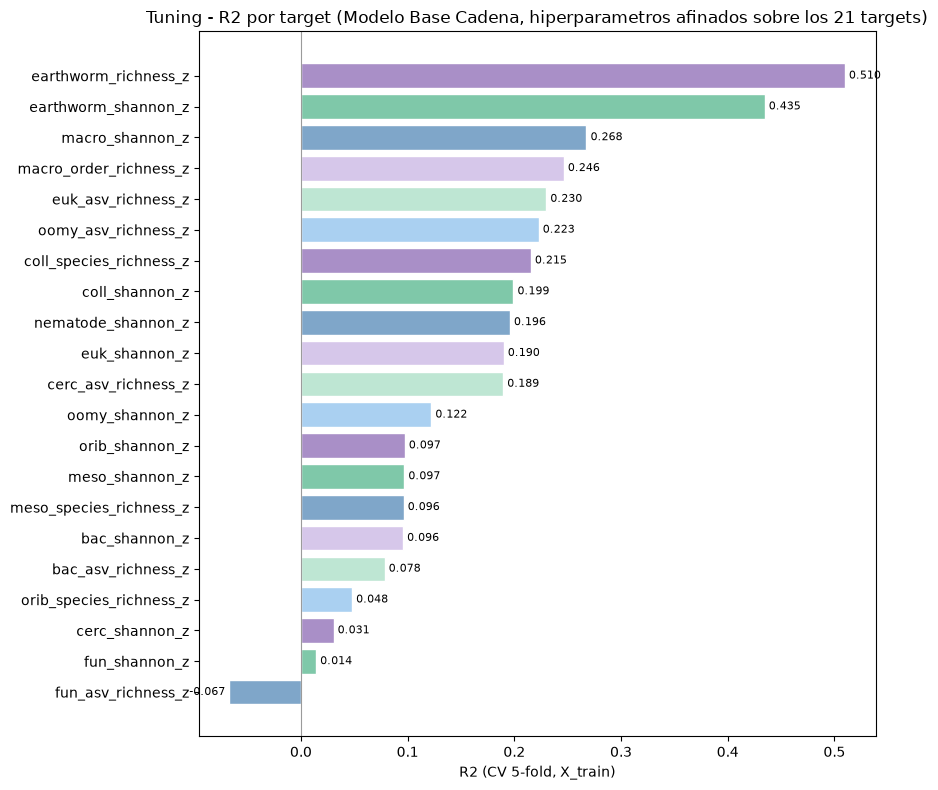

In [4]:
print('Iniciando busqueda de hiperparametros del modelo base...')
print('La busqueda evalua el R2 promedio sobre los 21 targets simultaneamente (no solo 2 de referencia).\n')

# Espacio de busqueda ampliado
param_grid_frenado = {
	'n_estimators':      [100, 150, 200],
	'max_depth':         [3, 4, 5, 10, 15, 20],
	'min_samples_leaf':  [2, 4, 8, 12, 16],
	'min_samples_split': [15, 20, 25],
	'max_features':      ['sqrt', 0.2, 0.3],
	'max_samples':       [0.7, 0.8],
	'ccp_alpha':         [0.005, 0.01, 0.02],
	'bootstrap':         [True],
	'random_state':      [RANDOM_STATE]
}

start_total = time.time()

# RandomForestRegressor admite y multivariante de forma nativa: al pasarle
# y_train completo (21 columnas), el scoring 'r2' de sklearn calcula el
# R2 de cada target y devuelve el promedio (multioutput='uniform_average').
buscador = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=param_grid_frenado,
    n_iter=50,
    scoring='r2',
    cv=5,
    verbose=0,
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS
)
buscador.fit(X_train, y_train)
elapsed = (time.time() - start_total) / 60

BASE_PARAMS = dict(buscador.best_params_)
BASE_PARAMS['random_state'] = RANDOM_STATE
BASE_PARAMS['n_jobs'] = N_JOBS

print(f'Busqueda completada en {elapsed:.1f} minutos.')
print(f'Mejor R2 promedio (21 targets, CV 5-fold): {buscador.best_score_:.4f}\n')
print('Hiperparametros optimos del modelo base:')
for k, v in BASE_PARAMS.items():
    print(f'  {k}: {v}')

# R2 individual por target del mejor modelo encontrado, para ver que tan
# representativo es el consenso de hiperparametros para cada variable objetivo
print('\nR2 individual por target (mismo modelo base, CV 5-fold):')
r2_por_target_base = {}
for target_col in TARGETS:
    scores = cross_validate(
        RandomForestRegressor(**BASE_PARAMS),
        X_train, y_train[target_col].values,
        cv=5, scoring='r2'
    )['test_score']
    r2_por_target_base[target_col] = np.mean(scores)
    print(f'  {target_col:30} {r2_por_target_base[target_col]:.4f}')

# Grafico: R2 por target del modelo base ya afinado
r2_series = pd.Series(r2_por_target_base).sort_values()
fig, ax = plt.subplots(figsize=(9, 8))
_bars = ax.barh(r2_series.index, r2_series.values,
                 color=palette_cycle(len(r2_series)), edgecolor='white')
ax.bar_label(_bars, fmt='{:.3f}', padding=3, fontsize=8)
ax.set_xlabel('R2 (CV 5-fold, X_train)')
ax.set_title('Tuning - R2 por target (Modelo Base Cadena, hiperparametros afinados sobre los 21 targets)', fontsize=12)
ax.axvline(0, color=PALETTE['gray'], linewidth=0.8)
plt.tight_layout()
plt.show()

## 4.- Validación cruzada

Se evalua la robustez de una cadena única (orden por defecto) con **validación cruzada repetida** (5 pliegues x 3 repeticiones) sobre `X_train`. 

El ensemble de cadenas aleatorias que se entrena en producción será más robusto que esta cadena única, por lo que estos resultados son una estimacióon conservadora del rendimiento final.

In [5]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RepeatedKFold, cross_validate

print('Validacion cruzada repetida (Modelos Independientes + Seleccion de Variables)...\n')

# Número de mejores predictores a conservar individualmente por target
K_BEST_FEATURES = 8

cv_splitter = RepeatedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_STATE)
resultados_cv_por_target = {}

header = f"{'TARGET':<26} | {'TRAIN R2':<10} | {'CV R2':<10} | {'DIFF':<10} | {'ESTADO'}"
print(header)
print('-' * len(header))

for target_col in TARGETS:
    y_target = y_train[target_col].values

    # Opción B: Obtener hiperparámetros específicos del target de forma segura
    params_target = BASE_PARAMS.get(target_col, BASE_PARAMS)

    # Pipeline individual: Filtrado de características + Random Forest regularizado
    pipeline_modelo = Pipeline([
        ('selector', SelectKBest(score_func=f_regression, k=K_BEST_FEATURES)),
        ('rf', RandomForestRegressor(
            **params_target
        ))
    ])

    resultados = cross_validate(
        estimator=pipeline_modelo,
        X=X_train,
        y=y_target,
        cv=cv_splitter,
        scoring=['r2'],
        return_train_score=True,
        n_jobs=N_JOBS
    )

    r2_train   = np.mean(resultados['train_r2'])
    r2_cv      = np.mean(resultados['test_r2'])
    diferencia = r2_train - r2_cv

    resultados_cv_por_target[target_col] = {'train_r2': r2_train, 'cv_r2': r2_cv}

    estado = "Aviso: Posible sobreajuste" if diferencia > 0.15 else "OK"

    print(f"{target_col:<26} | {r2_train:<10.3f} | {r2_cv:<10.3f} | {diferencia:<10.3f} | {estado}")

Validacion cruzada repetida (Modelos Independientes + Seleccion de Variables)...

TARGET                     | TRAIN R2   | CV R2      | DIFF       | ESTADO
--------------------------------------------------------------------------


nematode_shannon_z         | 0.422      | 0.211      | 0.211      | Aviso: Posible sobreajuste


macro_shannon_z            | 0.398      | 0.147      | 0.251      | Aviso: Posible sobreajuste


earthworm_shannon_z        | 0.516      | 0.264      | 0.252      | Aviso: Posible sobreajuste


orib_shannon_z             | 0.363      | 0.086      | 0.277      | Aviso: Posible sobreajuste


...

bac_asv_richness_z         | 0.320      | 0.009      | 0.312      | Aviso: Posible sobreajuste


fun_asv_richness_z         | 0.270      | -0.031     | 0.301      | Aviso: Posible sobreajuste


euk_asv_richness_z         | 0.415      | 0.140      | 0.275      | Aviso: Posible sobreajuste


oomy_asv_richness_z        | 0.421      | 0.178      | 0.242      | Aviso: Posible sobreajuste


cerc_asv_richness_z        | 0.433      | 0.194      | 0.239      | Aviso: Posible sobreajuste


## 5.- Análisis de la cadena

Se analiza el efecto del orden de la cadena en el rendimiento por target. Los targets al principio de la cadena solo tienen acceso a las variables originales, mientras que los del final tienen además las predicciones de todos los anteriores.

Se muestra también la importancia de variables del modelo base para el primer target de la cadena, donde no hay predicciones previas disponibles y la dificultad es máxima.

Analisis del efecto del orden en la cadena...

Entrenando cadena de referencia (orden por defecto) sobre X_train...


Cadena de referencia entrenada.

  Posicion en cadena -> target -> R2 (train):
    Posicion  1 | nematode_shannon_z             R2: 0.5360
    Posicion  2 | macro_shannon_z                R2: 0.5716
    Posicion  3 | earthworm_shannon_z            R2: 0.6845
    Posicion  4 | orib_shannon_z                 R2: 0.4661
    Posicion  5 | meso_shannon_z                 R2: 0.3856
    Posicion  6 | coll_shannon_z                 R2: 0.4848
    Posicion  7 | bac_shannon_z                  R2: 0.3535
    Posicion  8 | fun_shannon_z                  R2: 0.4075
    Posicion  9 | euk_shannon_z                  R2: 0.4838
    Posicion 10 | oomy_shannon_z                 R2: 0.4831
    Posicion 11 | cerc_shannon_z                 R2: 0.2869
    Posicion 12 | macro_order_richness_z         R2: 0.5382
    Posicion 13 | earthworm_richness_z           R2: 0.7398
    Posicion 14 | orib_species_richness_z        R2: 0.3531
    Posicion 15 | meso_species_richness_z        R2: 0.3075
    Posicion 16 | col

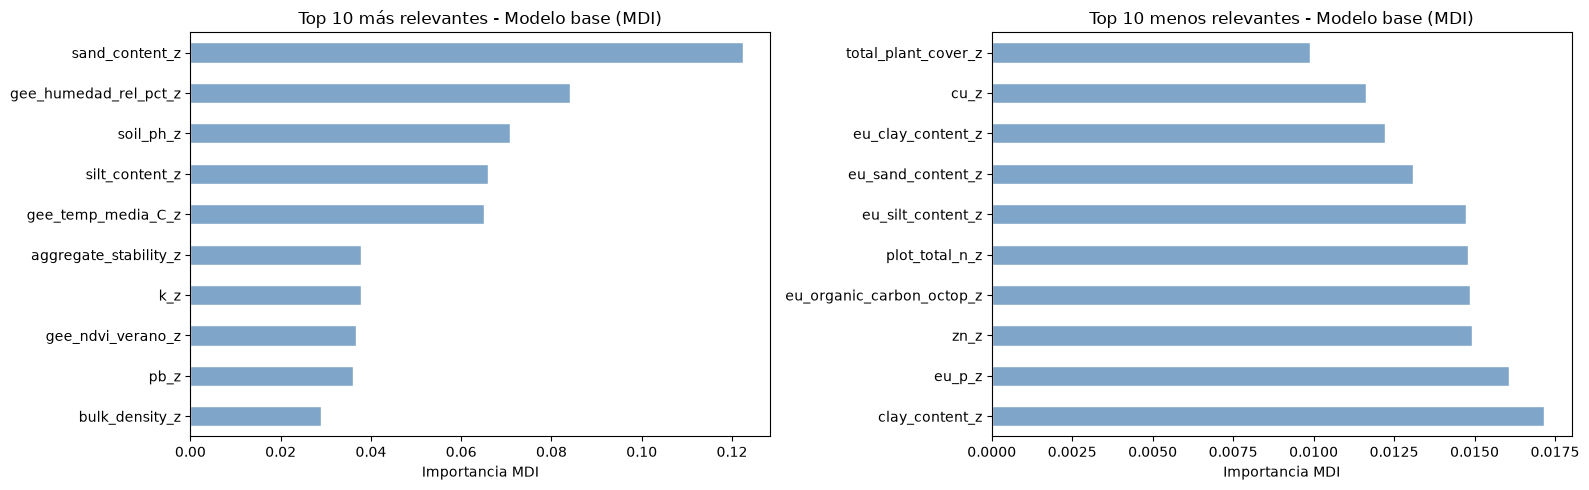


Gráfico SHAP summary plot (primer target):


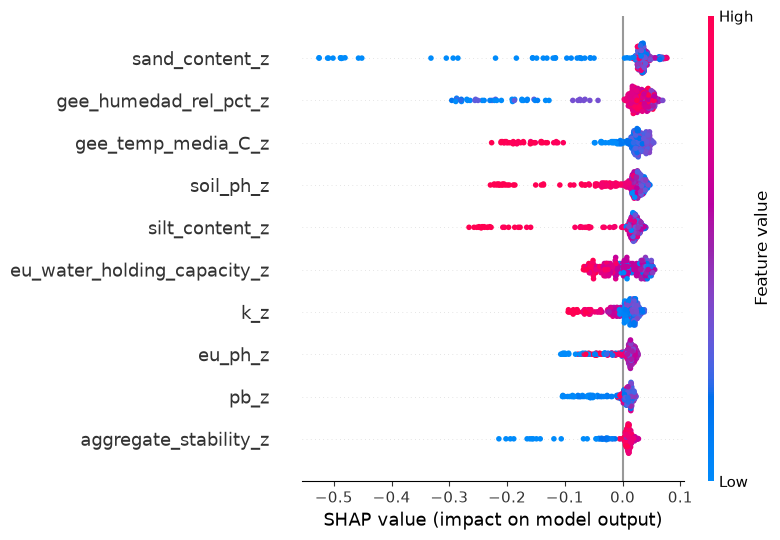

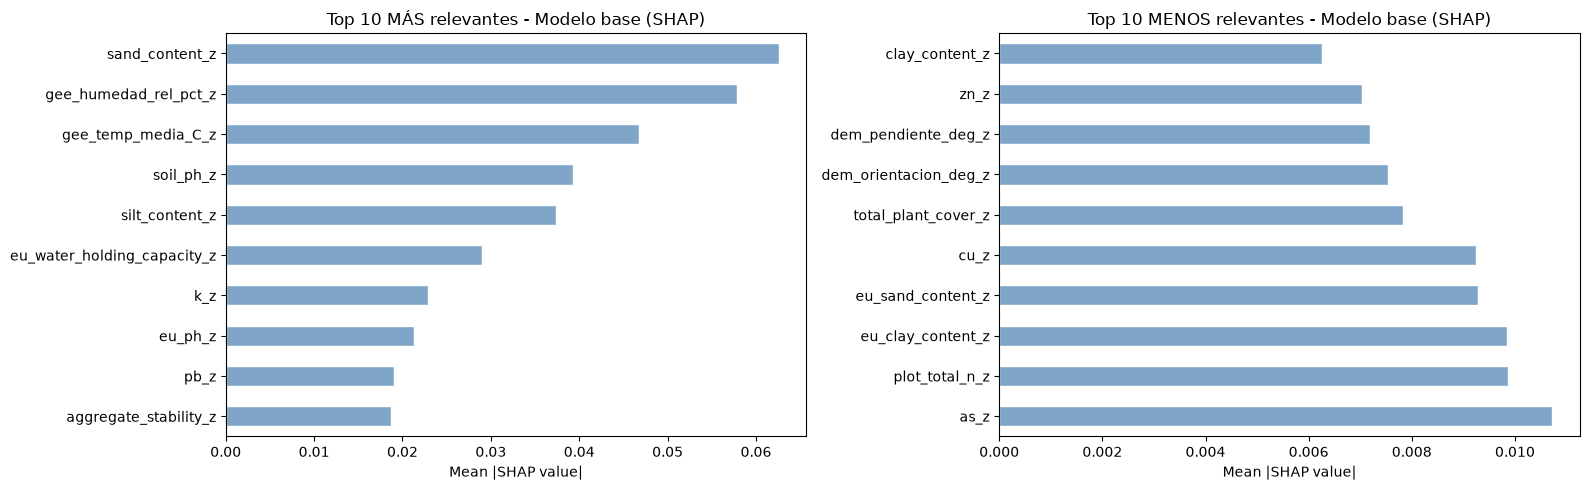

Datos exportados correctamente para revisión en : ./output/var/variables_mas_relevantes_cadena_shap.csv
Datos exportados correctamente para revisión en : ./output/var/variables_menos_relevantes_cadena_shap.csv


In [6]:
print('Analisis del efecto del orden en la cadena...\n')

print('Entrenando cadena de referencia (orden por defecto) sobre X_train...')
cadena_cv = RegressorChain(
    RandomForestRegressor(**BASE_PARAMS),
    order=list(range(len(TARGETS))),
    random_state=RANDOM_STATE
)
cadena_cv.fit(X_train, y_train)
y_pred_train = cadena_cv.predict(X_train)
print('Cadena de referencia entrenada.\n')

print('  Posicion en cadena -> target -> R2 (train):')
for i, t in enumerate(TARGETS):
    r2 = r2_score(y_train.iloc[:, i], y_pred_train[:, i])
    print(f'    Posicion {i+1:2d} | {t:30} R2: {r2:.4f}')

primer_modelo = cadena_cv.estimators_[0]
imp_mdi = pd.Series(primer_modelo.feature_importances_, index=FEATURES_AUTORIZADAS)

top10_mdi = imp_mdi.nlargest(10)
bottom10_mdi = imp_mdi.nsmallest(10)

print('\n  Top 10 variables más relevantes (MDI - Primer Target):')
print(top10_mdi.round(4).to_string())

print('\n  Top 10 variables menos relevantes (MDI - Primer Target):')
print(bottom10_mdi.round(4).to_string())

fig, axes_mdi = plt.subplots(1, 2, figsize=(16, 5))

top10_mdi.sort_values().plot(kind='barh', ax=axes_mdi[0], color=PALETTE['blue'], edgecolor='white')
axes_mdi[0].set_title('Top 10 más relevantes - Modelo base (MDI)', fontsize=12)
axes_mdi[0].set_xlabel('Importancia MDI')

bottom10_mdi.sort_values(ascending=False).plot(kind='barh', ax=axes_mdi[1], color=PALETTE['blue'], edgecolor='white')
axes_mdi[1].set_title('Top 10 menos relevantes - Modelo base (MDI)', fontsize=12)
axes_mdi[1].set_xlabel('Importancia MDI')

plt.tight_layout()
plt.show()

explainer   = shap.TreeExplainer(primer_modelo)
shap_values = explainer.shap_values(X_train)

if isinstance(shap_values, list):
    shap_arr = np.mean([np.abs(sv) for sv in shap_values], axis=0)
elif hasattr(shap_values, 'ndim') and shap_values.ndim == 3:
    shap_arr = np.abs(shap_values).mean(axis=2)
else:
    shap_arr = shap_values

print('\nGráfico SHAP summary plot (primer target):')
shap.summary_plot(shap_arr, X_train, plot_type='dot', max_display=10)

mean_abs_shap = np.abs(shap_arr).mean(axis=0)
imp_shap = pd.Series(mean_abs_shap, index=FEATURES_AUTORIZADAS)

top10_shap = imp_shap.nlargest(10)
bottom10_shap = imp_shap.nsmallest(10)

ruta_top_shap = './output/var/variables_mas_relevantes_cadena_shap.csv'
ruta_bottom_shap = './output/var/variables_menos_relevantes_cadena_shap.csv'

top10_shap.to_csv(ruta_top_shap, header=['mean_abs_shap'], index_label='variable')
bottom10_shap.to_csv(ruta_bottom_shap, header=['mean_abs_shap'], index_label='variable')

fig, axes_shap = plt.subplots(1, 2, figsize=(16, 5))

top10_shap.sort_values().plot(kind='barh', ax=axes_shap[0], color=PALETTE['blue'], edgecolor='white')
axes_shap[0].set_title('Top 10 MÁS relevantes - Modelo base (SHAP)', fontsize=12)
axes_shap[0].set_xlabel('Mean |SHAP value|')

bottom10_shap.sort_values(ascending=False).plot(kind='barh', ax=axes_shap[1], color=PALETTE['blue'], edgecolor='white')
axes_shap[1].set_title('Top 10 MENOS relevantes - Modelo base (SHAP)', fontsize=12)
axes_shap[1].set_xlabel('Mean |SHAP value|')

plt.tight_layout()
plt.show()

print(f"Datos exportados correctamente para revisión en : {ruta_top_shap}")
print(f"Datos exportados correctamente para revisión en : {ruta_bottom_shap}")

## 6.- Entrenamiento

Se entrenan 10 cadenas con ordenes aleatorios distintos. 

Cada cadena usa el mismo modelo base (Random Forest con los hiperparámetros óptimos) pero un orden diferente de los targets.

Al promediar las predicciones de todas las cadenas, se compensan los errores de acumulación que afectan a los targets al principio de cada cadena.

In [7]:
print(f'Entrenamiento de produccion ({N_CHAINS} cadenas con ordenes aleatorios)...')
print('-' * 70)

global_start = time.time()
ordenes_usados = []

for chain_id in range(N_CHAINS):
    t0 = time.time()

    # Cada cadena usa un orden aleatorio distinto de los 11 targets
    orden = list(np.random.RandomState(RANDOM_STATE + chain_id).permutation(len(TARGETS)))
    ordenes_usados.append(orden)

    base_model = RandomForestRegressor(**{**BASE_PARAMS, 'random_state': RANDOM_STATE + chain_id})
    cadena     = RegressorChain(base_model, order=orden)
    cadena.fit(X_train, y_train)

    joblib.dump(cadena, os.path.join(MODELS_DIR, f'chain_{chain_id}.pkl'))
    print(f'  Cadena {chain_id+1:2d}/{N_CHAINS} | orden: {orden} | ({time.time()-t0:.1f}s)')

# Guardamos los ordenes para referencia futura
joblib.dump(ordenes_usados, os.path.join(MODELS_DIR, 'ordenes.pkl'))

print('-' * 70)
print(f'Produccion completada en {(time.time()-global_start)/60:.1f} minutos.')

Entrenamiento de produccion (10 cadenas con ordenes aleatorios)...
----------------------------------------------------------------------


  Cadena  1/10 | orden: [np.int64(0), np.int64(17), np.int64(15), np.int64(1), np.int64(8), np.int64(5), np.int64(11), np.int64(3), np.int64(18), np.int64(16), np.int64(13), np.int64(2), np.int64(9), np.int64(20), np.int64(4), np.int64(12), np.int64(7), np.int64(10), np.int64(14), np.int64(19), np.int64(6)] | (3.7s)


  Cadena  2/10 | orden: [np.int64(20), np.int64(12), np.int64(8), np.int64(5), np.int64(6), np.int64(11), np.int64(10), np.int64(13), np.int64(1), np.int64(9), np.int64(18), np.int64(3), np.int64(19), np.int64(7), np.int64(15), np.int64(14), np.int64(2), np.int64(16), np.int64(17), np.int64(0), np.int64(4)] | (3.6s)


  Cadena  3/10 | orden: [np.int64(15), np.int64(14), np.int64(9), np.int64(2), np.int64(5), np.int64(11), np.int64(18), np.int64(1), np.int64(6), np.int64(12), np.int64(7), np.int64(8), np.int64(10), np.int64(16), np.int64(4), np.int64(0), np.int64(19), np.int64(13), np.int64(17), np.int64(3), np.int64(20)] | (3.7s)


  Cadena  4/10 | orden: [np.int64(13), np.int64(17), np.int64(20), np.int64(2), np.int64(16), np.int64(12), np.int64(18), np.int64(10), np.int64(7), np.int64(14), np.int64(6), np.int64(15), np.int64(5), np.int64(1), np.int64(8), np.int64(9), np.int64(4), np.int64(19), np.int64(0), np.int64(3), np.int64(11)] | (3.7s)


...

  Cadena  6/10 | orden: [np.int64(12), np.int64(4), np.int64(16), np.int64(15), np.int64(5), np.int64(19), np.int64(2), np.int64(9), np.int64(1), np.int64(10), np.int64(13), np.int64(14), np.int64(11), np.int64(18), np.int64(0), np.int64(3), np.int64(17), np.int64(8), np.int64(20), np.int64(6), np.int64(7)] | (3.7s)


  Cadena  7/10 | orden: [np.int64(1), np.int64(9), np.int64(5), np.int64(7), np.int64(8), np.int64(12), np.int64(18), np.int64(3), np.int64(11), np.int64(10), np.int64(13), np.int64(15), np.int64(2), np.int64(14), np.int64(6), np.int64(20), np.int64(16), np.int64(4), np.int64(17), np.int64(19), np.int64(0)] | (3.7s)


  Cadena  8/10 | orden: [np.int64(15), np.int64(20), np.int64(9), np.int64(6), np.int64(19), np.int64(7), np.int64(18), np.int64(3), np.int64(11), np.int64(0), np.int64(4), np.int64(2), np.int64(1), np.int64(17), np.int64(14), np.int64(16), np.int64(5), np.int64(12), np.int64(8), np.int64(13), np.int64(10)] | (3.6s)


  Cadena  9/10 | orden: [np.int64(20), np.int64(9), np.int64(10), np.int64(19), np.int64(3), np.int64(15), np.int64(8), np.int64(7), np.int64(2), np.int64(12), np.int64(18), np.int64(17), np.int64(5), np.int64(6), np.int64(4), np.int64(14), np.int64(1), np.int64(13), np.int64(11), np.int64(0), np.int64(16)] | (3.7s)


  Cadena 10/10 | orden: [np.int64(1), np.int64(12), np.int64(19), np.int64(2), np.int64(7), np.int64(6), np.int64(3), np.int64(8), np.int64(13), np.int64(11), np.int64(10), np.int64(15), np.int64(18), np.int64(4), np.int64(14), np.int64(17), np.int64(16), np.int64(20), np.int64(9), np.int64(0), np.int64(5)] | (3.6s)
----------------------------------------------------------------------
Produccion completada en 0.6 minutos.


## 7.- Evaluación final sobre eval.csv

Se usa `eval.csv` por primera vez para obtener una estimación real del rendimiento en producción. 
A continuación se ejecuta un smoke test para verificar que el pipeline de carga e inferencia funciona correctamente.

**Nota: Interpretacion del indice Shannon H':**

El modelo predice el índice de diversidad de Shannon, que va aproximadamente de `0.0` (sin diversidad) a `4.0-5.0` (alta diversidad biologica).

Evaluacion final sobre eval.csv
------------------------------------------------------------


  R2   global: 0.0813
  RMSE global: 0.9174 puntos de Shannon H'
  MAE  global: 0.6859 puntos de Shannon H'

  R2 por target:
    nematode_shannon_z             0.1406
    macro_shannon_z                0.2828
    earthworm_shannon_z            0.4906
    orib_shannon_z                 0.2071
    meso_shannon_z                 -0.1582
    coll_shannon_z                 -0.6818
    bac_shannon_z                  0.0316
    fun_shannon_z                  -0.0205
    euk_shannon_z                  0.1532
    oomy_shannon_z                 0.0953
    cerc_shannon_z                 0.0151
    macro_order_richness_z         0.4052
    earthworm_richness_z           0.5309
    orib_species_richness_z        0.2106
    meso_species_richness_z        -0.0236
    coll_species_richness_z        -0.5619
    bac_asv_richness_z             0.0013
    fun_asv_richness_z             -0.0192
    euk_asv_richness_z             0.2773
    oomy_asv_richness_z            0.2130
    cerc_asv_richness_z     

  Cadena  1 | Fila 53: 0.5236 | Fila 60: 0.7445 | Fila 0: -0.4246  (earthworm_shannon_z)


  Cadena  2 | Fila 53: 0.7030 | Fila 60: 0.9121 | Fila 0: -0.1311  (earthworm_shannon_z)


  Cadena  3 | Fila 53: 0.5255 | Fila 60: 0.8848 | Fila 0: -0.5541  (earthworm_shannon_z)


...

  Cadena  6 | Fila 53: 0.6566 | Fila 60: 0.9194 | Fila 0: -0.5246  (earthworm_shannon_z)


  Cadena  7 | Fila 53: 0.6431 | Fila 60: 0.8487 | Fila 0: -0.1083  (earthworm_shannon_z)


  Cadena  8 | Fila 53: 0.5268 | Fila 60: 0.7993 | Fila 0: -0.4386  (earthworm_shannon_z)


  Cadena  9 | Fila 53: 0.5507 | Fila 60: 0.7567 | Fila 0: -0.4075  (earthworm_shannon_z)


  Cadena 10 | Fila 53: 0.6569 | Fila 60: 0.9626 | Fila 0: -0.6325  (earthworm_shannon_z)
------------------------------------------------------------
  Resultados detallados por muestra (earthworm_shannon_z):
------------------------------------------------------------
    Fila 53   | Prediccion: 0.5864 | Valor Real: 1.1347 | Error absoluto: 0.5483
    Fila 60   | Prediccion: 0.8408 | Valor Real: 1.1388 | Error absoluto: 0.2980
    Fila 0    | Prediccion: -0.3771 | Valor Real: -0.7453 | Error absoluto: 0.3681
------------------------------------------------------------

Smoke test superado. El ensemble de cadenas funciona correctamente.


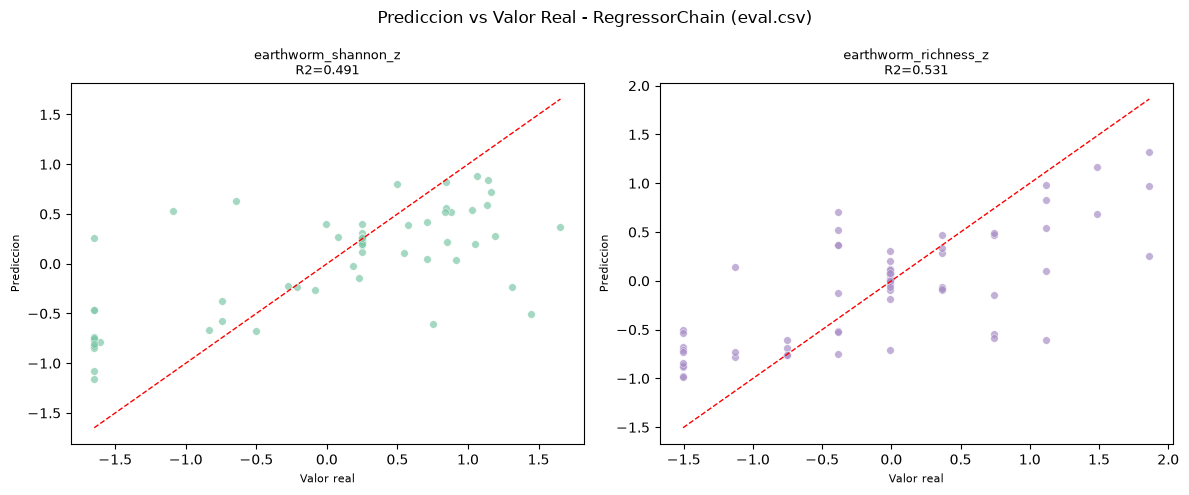

In [8]:

# Evaluacion final
# Cargamos las N cadenas y promediamos sus predicciones sobre eval.csv.

print('Evaluacion final sobre eval.csv')
print('-' * 60)

preds_eval = []
for chain_id in range(N_CHAINS):
    ruta   = os.path.join(MODELS_DIR, f'chain_{chain_id}.pkl')
    cadena = joblib.load(ruta)
    preds_eval.append(cadena.predict(X_eval))

# Promediamos sobre todas las cadenas: shape (N_CHAINS, n_eval, 11) -> (n_eval, 11)
y_pred_eval = np.mean(preds_eval, axis=0)
y_true_eval = y_eval.values

r2_global   = r2_score(y_true_eval, y_pred_eval, multioutput='uniform_average')
rmse_global = np.sqrt(mean_squared_error(y_true_eval, y_pred_eval, multioutput='uniform_average'))
mae_global  = mean_absolute_error(y_true_eval, y_pred_eval, multioutput='uniform_average')

print(f'  R2   global: {r2_global:.4f}')
print(f'  RMSE global: {rmse_global:.4f} puntos de Shannon H\'')
print(f'  MAE  global: {mae_global:.4f} puntos de Shannon H\'')

print('\n  R2 por target:')
r2_por_target = r2_score(y_true_eval, y_pred_eval, multioutput='raw_values')
for t, r2 in zip(TARGETS, r2_por_target):
    print(f'    {t:30} {r2:.4f}')


# Smoke test con datos reales

print('\nSmoke test - Inferencia con datos reales')
print('-' * 60)

try:
    df_new_data      = X_eval.sample(n=3, random_state=RANDOM_STATE)
    indices_elegidos = df_new_data.index
    valores_reales   = y_eval.loc[indices_elegidos].values

    votos = []
    for chain_id in range(N_CHAINS):
        ruta   = os.path.join(MODELS_DIR, f'chain_{chain_id}.pkl')
        cadena = joblib.load(ruta)
        pred   = cadena.predict(df_new_data)
        votos.append(pred)
        # pred es una matriz (3 muestras x 11 targets)
        print(f'  Cadena {chain_id+1:2d} | '
              f'Fila {indices_elegidos[0]}: {pred[0, 2]:.4f} | '
              f'Fila {indices_elegidos[1]}: {pred[1, 2]:.4f} | '
              f'Fila {indices_elegidos[2]}: {pred[2, 2]:.4f}  (earthworm_shannon_z)')

    consenso = np.mean(votos, axis=0)
    print('-' * 60)
    print('  Resultados detallados por muestra (earthworm_shannon_z):')
    print('-' * 60)

    idx_earth = TARGETS.index('earthworm_shannon_z')
    for i, idx in enumerate(indices_elegidos):
        pred_val = consenso[i, idx_earth]
        real_val = y_eval.loc[idx, 'earthworm_shannon_z']
        error    = abs(pred_val - real_val)
        print(f'    Fila {idx:<4} | Prediccion: {pred_val:.4f} | '
              f'Valor Real: {real_val:.4f} | Error absoluto: {error:.4f}')

    print('-' * 60)
    print('\nSmoke test superado. El ensemble de cadenas funciona correctamente.')

except Exception as e:
    print(f'Error en el smoke test: {str(e)}')

# Grafico: scatter prediccion vs valor real (targets principales)
_targets_plot = ['earthworm_shannon_z', 'earthworm_richness_z']
_colors_plot  = [PALETTE['green'], PALETTE['purple']]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, tgt, col in zip(axes, _targets_plot, _colors_plot):
    idx_col = TARGETS.index(tgt)
    yp = y_pred_eval[:, idx_col]
    yt = y_true_eval[:, idx_col]
    ax.scatter(yt, yp, alpha=0.7, s=30, color=col, edgecolors='white', linewidths=0.4)
    lim = [min(yt.min(), yp.min()), max(yt.max(), yp.max())]
    ax.plot(lim, lim, 'r--', linewidth=1)
    ax.set_title(f'{tgt}\nR2={r2_score(yt, yp):.3f}', fontsize=9)
    ax.set_xlabel('Valor real', fontsize=8)
    ax.set_ylabel('Prediccion', fontsize=8)
plt.suptitle('Prediccion vs Valor Real - RegressorChain (eval.csv)', fontsize=12)
plt.tight_layout()
plt.show()